# 大类资产配置回测（股债性价比 + 黄金/铜动量叠加）

本 Notebook 用于复现实证：以 **股债性价比（ERP）** 为核心信号，在 **股票/债券** 间做动态配置，并叠加 **黄金、铜** 的动量权重。

- **数据源**：`yfinance`（在线）或本地 CSV（离线）；
- **再平衡频率**：月度；
- **输出**：策略净值、基准（多股、多债、60/40）、权重图、ERP 序列、绩效指标等；
- **全部中文注释**，便于直接写入论文第三部分。


## 使用说明

1. **推荐**：在本地或服务器/云笔记本（如 VS Code、JupyterLab）中运行。
2. 若使用 **在线数据**，需保证可以访问 `yfinance`。若网络受限，请使用 **本地 CSV 模式**（见下方参数）。
3. **本地 CSV 模式**需要在指定目录放入：
   - `equity.csv`（股票指数或 ETF 价格）
   - `bond.csv`（债券 ETF 价格；或债券收益率，若用收益率需在参数里声明）
   - `gold.csv`（可选，黄金）
   - `copper.csv`（可选，铜）
   - `ep.csv`（可选，盈利收益率 E/P，十进制，如 0.07）
   - `dividend_yield.csv`（可选，股息率，十进制，如 0.025）
     > CSV 至少包含两列：`Date`（YYYY-MM-DD）与一个数值列（价格/收益率）。


In [1]:
# ============== 环境依赖（按需）==============
# 如果本地没有安装这些库，取消下一行注释进行安装：
# !pip install -U yfinance pandas numpy matplotlib

import os
import math
from dataclasses import dataclass
from typing import Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Matplotlib 中文显示（需本地已安装中文字体，可按需更改）
plt.rcParams["font.family"] = ["SimHei", "Microsoft YaHei", "Arial"]
plt.rcParams["axes.unicode_minus"] = False  # 负号正常显示

In [2]:
# ============== 工具函数 ==============


def ensure_dirs():
    """确保输出目录存在"""
    os.makedirs("figures", exist_ok=True)
    os.makedirs("outputs", exist_ok=True)


def clip(series: pd.Series, start: str = None, end: str = None) -> pd.Series:
    """按全局 START_DATE/END_DATE 或显式传入的 start/end 裁剪日期。"""
    s = series.copy()
    s.index = pd.to_datetime(s.index)
    s = s.sort_index()
    st = start or START_DATE
    ed = end or END_DATE
    if st:
        s = s[s.index >= pd.to_datetime(st)]
    if ed:
        s = s[s.index <= pd.to_datetime(ed)]
    return s


def resample_month_end(series: pd.Series) -> pd.Series:
    """按月末重采样为月频（使用 'ME'，避免 'M' 弃用警告）。"""
    return series.resample("ME").last()


def pct_change_rolling(series: pd.Series, months: int = 12) -> pd.Series:
    """按 N 个月计算简单收益率（基于月末数据）。"""
    return series.pct_change(periods=months)


def momentum_days(series: pd.Series, lookback_days: int = 120) -> pd.Series:
    """按日频价格计算 N 天动量（百分比变化）。"""
    return series.pct_change(lookback_days)


def to_monthly_index(df: pd.DataFrame) -> pd.DataFrame:
    """将 DataFrame 对齐到月末索引。"""
    return df.resample("ME").last()


def annualize_vol(ser: pd.Series, periods_per_year: int = 12) -> float:
    """年化波动率（基于月频收益）。"""
    return ser.std(ddof=0) * math.sqrt(periods_per_year)


def sharpe_ratio(ser: pd.Series, rf: float = 0.0, periods_per_year: int = 12) -> float:
    """夏普比率：年化超额收益 / 年化波动"""
    excess = ser - rf
    vol = excess.std(ddof=0)
    if vol == 0 or np.isnan(vol):
        return np.nan
    return excess.mean() / vol * math.sqrt(periods_per_year)


def max_drawdown(cum: pd.Series) -> float:
    """最大回撤（基于累计净值）。"""
    rollmax = cum.cummax()
    dd = cum / rollmax - 1.0
    return dd.min()


def compute_growth_rate(series: pd.Series, months: int = 12) -> pd.Series:
    """按 N 个月的涨跌幅近似增长率。"""
    return series.pct_change(periods=months)


def read_csv_series(path: str) -> pd.Series:
    """读取 CSV 为时间序列（要求含 Date 列）。"""
    df = pd.read_csv(path)
    date_col = "Date" if "Date" in df.columns else "date"
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.set_index(date_col).sort_index()
    # 使用除日期外的第一列作为数值列
    val_col = [c for c in df.columns if c.lower() not in ("date",)][0]
    return df[val_col].astype(float)


def fetch_yf_series(
    ticker: str, price_col: str = "Adj Close", start: str = None, end: str = None
) -> pd.Series:
    """通过 yfinance 下载某个标的的价格序列，可指定日期范围。"""
    import yfinance as yf

    data = yf.download(
        ticker,
        auto_adjust=False,
        progress=False,
        start=start or START_DATE,
        end=end or END_DATE,
    )
    if data.empty:
        raise RuntimeError(f"未获取到 {ticker} 的数据，请检查网络或代码。")
    if price_col not in data.columns:
        price_col = "Close" if "Close" in data.columns else data.columns[0]
    ser = data[price_col].copy()
    ser.index = pd.to_datetime(ser.index)
    ser = ser.sort_index()
    return ser


@dataclass
class Inputs:
    equity: pd.Series
    bond: pd.Series
    gold: Optional[pd.Series] = None
    copper: Optional[pd.Series] = None
    bond_is_yield: bool = False  # True 表示 bond 是年化收益率（小数），而非价格

In [3]:
# ============== ERP 三种口径与回测核心（中文注释）==============


def erp_ep(earnings_yield: pd.Series, bond_yield: pd.Series) -> pd.Series:
    """ERP = E/P - 债券收益率"""
    return (earnings_yield - bond_yield).dropna()


def erp_divgrow(
    div_yield: pd.Series,
    equity_price: pd.Series,
    bond_yield: pd.Series,
    months: int = 12,
) -> pd.Series:
    """ERP = 股息率 + 价格增长率 - 债券收益率（增长率用过去N个月涨跌幅近似）"""
    growth = compute_growth_rate(equity_price, months=months)
    exp_equity = div_yield.add(growth, fill_value=0.0)
    return (exp_equity - bond_yield).dropna()


def erp_ret_minus_yield(
    equity_price: pd.Series, bond_yield: pd.Series, months: int = 12
) -> pd.Series:
    """ERP = 股市过去N个月收益率 - 债券收益率（鲁棒、数据易得）"""
    trailing_ret = compute_growth_rate(equity_price, months=months)
    return (trailing_ret - bond_yield).dropna()


def total_return(price: pd.Series) -> pd.Series:
    """由价格计算月度简单收益率。若是总回报ETF则已含分红。"""
    return price.pct_change().fillna(0.0)


def bond_yield_to_return(yield_annual: pd.Series, dur_years: float = 7.0) -> pd.Series:
    """
    将年化收益率序列近似映射为债券月度回报：
    月度回报 ≈ 当月票息（年化收益率/12） + 久期*(-Δ收益率)
    这是线性近似，目的在于无ETF价格时提供一个可用的回报序列。
    """
    y = yield_annual.astype(float)
    y_m = y / 12.0
    dy = y.diff().fillna(0.0)
    ret = y_m - dur_years * dy
    return ret


def backtest(
    equity_price: pd.Series,
    bond_series: pd.Series,
    gold_price: Optional[pd.Series],
    copper_price: Optional[pd.Series],
    bond_is_yield: bool,
    erp_series: pd.Series,
    erp_threshold: float = 0.0,
    eq_over=0.8,
    bd_over=0.2,
    eq_under=0.2,
    bd_under=0.8,
    gold_mom_lb: int = 120,
    copper_mom_lb: int = 120,
    gold_cap: float = 0.10,
    copper_cap: float = 0.10,
) -> pd.DataFrame:
    """
    回测主体：
    - ERP > 阈值：股票80%/债券20%；否则：股票20%/债券80%
    - 若黄金/铜的动量（120天）>0，各自最多加到10%权重，从股+债按比例挤出
    - 所有权重按月末信号在下一月生效（避免未来函数）
    返回列：权重、各资产收益、策略收益/净值、基准等
    """
    df = pd.DataFrame({"equity": equity_price})
    if bond_is_yield:
        df["bond_yield"] = bond_series
    else:
        df["bond_price"] = bond_series
    if gold_price is not None:
        df["gold"] = gold_price
    if copper_price is not None:
        df["copper"] = copper_price

    df = to_monthly_index(df).dropna(how="any")
    erp_m = erp_series.reindex(df.index).ffill().dropna()
    df = df.loc[erp_m.index]

    # 计算月度收益
    ret_eq = total_return(df["equity"])
    if bond_is_yield:
        ret_bd = bond_yield_to_return(df["bond_yield"])
    else:
        ret_bd = total_return(df["bond_price"])

    if "gold" in df.columns:
        ret_gold = total_return(df["gold"])
    else:
        ret_gold = pd.Series(0.0, index=df.index)
    if "copper" in df.columns:
        ret_copper = total_return(df["copper"])
    else:
        ret_copper = pd.Series(0.0, index=df.index)

    # ERP 决定的基础权重
    w_eq = pd.Series(
        np.where(erp_m > erp_threshold, eq_over, eq_under), index=df.index, dtype=float
    )
    w_bd = pd.Series(
        np.where(erp_m > erp_threshold, bd_over, bd_under), index=df.index, dtype=float
    )

    # 动量叠加权重（基于 120 天动量）
    w_gold = pd.Series(0.0, index=df.index, dtype=float)
    w_copper = pd.Series(0.0, index=df.index, dtype=float)

    if "gold" in df.columns:
        gold_mom = momentum_days(df["gold"], lookback_days=gold_mom_lb).reindex(
            df.index
        )
        w_gold = pd.Series(
            np.where(gold_mom > 0, gold_cap, 0.0), index=df.index, dtype=float
        )
    if "copper" in df.columns:
        copper_mom = momentum_days(df["copper"], lookback_days=copper_mom_lb).reindex(
            df.index
        )
        w_copper = pd.Series(
            np.where(copper_mom > 0, copper_cap, 0.0), index=df.index, dtype=float
        )

    # 按叠加比例缩放股/债，使总权重为 1
    overlay = (w_gold + w_copper).clip(0, 0.999)
    scale = 1.0 - overlay
    # 按原股债占比缩放
    base_sum = (w_eq + w_bd).replace(0, np.nan)
    w_eq = (w_eq / base_sum) * scale
    w_bd = (w_bd / base_sum) * scale
    w_eq = w_eq.fillna(0.0)
    w_bd = w_bd.fillna(0.0)

    # 最终权重与收益（采用上月权重）
    ret_strat = (
        w_eq.shift(1) * ret_eq
        + w_bd.shift(1) * ret_bd
        + w_gold.shift(1) * ret_gold
        + w_copper.shift(1) * ret_copper
    ).fillna(0.0)

    ret_6040 = (0.6 * ret_eq.shift(1) + 0.4 * ret_bd.shift(1)).fillna(0.0)

    out = pd.DataFrame(
        {
            "w_eq": w_eq,
            "w_bd": w_bd,
            "w_gold": w_gold,
            "w_copper": w_copper,
            "ret_strategy": ret_strat,
            "ret_eq": ret_eq,
            "ret_bd": ret_bd,
            "ret_6040": ret_6040,
        }
    )

    out["cum_strategy"] = (1 + out["ret_strategy"]).cumprod()
    out["cum_eq"] = (1 + out["ret_eq"]).cumprod()
    out["cum_bd"] = (1 + out["ret_bd"]).cumprod()
    out["cum_6040"] = (1 + out["ret_6040"]).cumprod()

    return out

In [4]:
# ============== 参数区（按需修改）==============
USE_YF = True  # True=在线 yfinance；False=离线 CSV 模式
CSV_DIR = "./data"  # 离线模式时，CSV 所在目录

# —— 常用标的 ——
EQUITY_TICKER = "000300.SS"  # A股：沪深300；美股：^GSPC；港股：^HSI
BOND_TICKER = "IEF"  # 债券：美债7-10年ETF IEF；或收益率 ^TNX（注意单位）
GOLD_TICKER = "GLD"  # 黄金：GLD；国内黄金ETF：518880.SS
COPPER_TICKER = "HG=F"  # 铜：COMEX 连续期货 HG=F；或 ETF CPER

BOND_IS_YIELD = (
    False  # 若 BOND_TICKER 是收益率（如 ^TNX），改为 True，并建议改为离线 CSV 更稳
)

# ERP 口径：'ret_minus_yield'（默认） / 'ep' / 'divgrow'
ERP_METHOD = "ret_minus_yield"

START_DATE = "2010-01-01"
END_DATE = None  # 如需截止日期，填 "2025-09-01"

# 策略配置参数
ERP_THRESHOLD = 0.0
EQ_OVER, BD_OVER = 0.8, 0.2
EQ_UNDER, BD_UNDER = 0.2, 0.8
GOLD_CAP, COPPER_CAP = 0.10, 0.10
MOM_LB_DAYS = 120  # 黄金/铜动量回看天数

In [5]:
# ============== 数据加载（新增完整历史抓取与裁剪）==============
print("开始加载数据 ...")
if USE_YF:
    equity = fetch_yf_series(EQUITY_TICKER)
    bond = fetch_yf_series(BOND_TICKER)
    gold = fetch_yf_series(GOLD_TICKER) if GOLD_TICKER else None
    copper = fetch_yf_series(COPPER_TICKER) if COPPER_TICKER else None
else:
    base = CSV_DIR
    equity = read_csv_series(os.path.join(base, "equity.csv"))
    bond = read_csv_series(os.path.join(base, "bond.csv"))
    gold = (
        read_csv_series(os.path.join(base, "gold.csv"))
        if os.path.exists(os.path.join(base, "gold.csv"))
        else None
    )
    copper = (
        read_csv_series(os.path.join(base, "copper.csv"))
        if os.path.exists(os.path.join(base, "copper.csv"))
        else None
    )

# 日期裁剪
for name in ["equity", "bond", "gold", "copper"]:
    obj = globals().get(name)
    if obj is not None:
        globals()[name] = clip(obj)

print("加载完成：")
print("equity range:", equity.index.min(), equity.index.max(), len(equity))
print("bond   range:", bond.index.min(), bond.index.max(), len(bond))
if gold is not None:
    print("gold   range:", gold.index.min(), gold.index.max(), len(gold))
if copper is not None:
    print("copper range:", copper.index.min(), copper.index.max(), len(copper))

开始加载数据 ...
加载完成：
equity range: 2021-03-11 00:00:00 2025-09-12 00:00:00 1097
bond   range: 2010-01-04 00:00:00 2025-09-11 00:00:00 3947
gold   range: 2010-01-04 00:00:00 2025-09-11 00:00:00 3947
copper range: 2010-01-04 00:00:00 2025-09-12 00:00:00 3948
加载完成：
equity range: 2021-03-11 00:00:00 2025-09-12 00:00:00 1097
bond   range: 2010-01-04 00:00:00 2025-09-11 00:00:00 3947
gold   range: 2010-01-04 00:00:00 2025-09-11 00:00:00 3947
copper range: 2010-01-04 00:00:00 2025-09-12 00:00:00 3948


In [6]:
# 资产数据裁剪与展示（改进：仅在变量存在时执行）
import pandas as pd
from IPython.display import display


def ensure_series(obj, name_hint=None):
    """将 DataFrame/Series/一列的 DataFrame 统一转换为 Series。
    - 若为 None 直接返回 None
    - 如果是 DataFrame 且只有一列，返回该列
    - 如果是 DataFrame 且多列，优先使用 name_hint；否则第一列
    """
    if obj is None:
        return None
    if isinstance(obj, pd.Series):
        return obj
    if isinstance(obj, pd.DataFrame):
        if obj.shape[1] == 1:
            return obj.iloc[:, 0]
        if name_hint and name_hint in obj.columns:
            return obj[name_hint]
        return obj.iloc[:, 0]
    raise TypeError(f"Unsupported type for ensure_series: {type(obj)}")


# 仅当前面数据加载单元已经成功创建 equity / bond 变量时再执行
_missing = [name for name in ["equity", "bond"] if name not in globals()]
if _missing:
    print("跳过裁剪展示：以下变量尚未定义 ->", _missing)
else:
    _equity = ensure_series(globals().get("equity"))
    _bond = ensure_series(globals().get("bond"))
    _gold = ensure_series(globals().get("gold")) if "gold" in globals() else None
    _copper = ensure_series(globals().get("copper")) if "copper" in globals() else None

    _equity = clip(_equity)
    _bond = clip(_bond)
    _gold = clip(_gold) if _gold is not None else None
    _copper = clip(_copper) if _copper is not None else None

    equity = _equity
    bond = _bond
    gold = _gold
    copper = _copper

    print("裁剪后区间：")
    print("equity:", equity.index.min(), "->", equity.index.max(), len(equity))
    print("bond  :", bond.index.min(), "->", bond.index.max(), len(bond))
    if gold is not None:
        print("gold  :", gold.index.min(), "->", gold.index.max(), len(gold))
    if copper is not None:
        print("copper:", copper.index.min(), "->", copper.index.max(), len(copper))

    display(equity.tail(3).to_frame(name="equity"))
    if BOND_IS_YIELD:
        display(bond.tail(3).to_frame(name="bond_yield"))
    else:
        display(bond.tail(3).to_frame(name="bond_price"))
    if gold is not None:
        display(gold.tail(3).to_frame(name="gold"))
    if copper is not None:
        display(copper.tail(3).to_frame(name="copper"))

裁剪后区间：
equity: 2021-03-11 00:00:00 -> 2025-09-12 00:00:00 1097
bond  : 2010-01-04 00:00:00 -> 2025-09-11 00:00:00 3947
gold  : 2010-01-04 00:00:00 -> 2025-09-11 00:00:00 3947
copper: 2010-01-04 00:00:00 -> 2025-09-12 00:00:00 3948


,equity
Date,
2025-09-10,4445.370117
2025-09-11,4548.040039
2025-09-12,4521.998047


,bond_price
Date,
2025-09-09,96.849998
2025-09-10,97.110001
2025-09-11,97.260002


,gold
Date,
2025-09-09,334.059998
2025-09-10,335.260010
2025-09-11,334.760010


,copper
Date,
2025-09-10,4.5500
2025-09-11,4.5905
2025-09-12,4.6460


In [7]:
# ============== 构造月频与 ERP ==============
eq_m = resample_month_end(equity).dropna()
bd_m = resample_month_end(bond).dropna()
gl_m = resample_month_end(gold).dropna() if gold is not None else None
cu_m = resample_month_end(copper).dropna() if copper is not None else None

# 债券收益率（若选择收益率口径则直接使用；否则用ETF价格粗略构造一个“收益率代理”以便计算 ERP）
if BOND_IS_YIELD:
    bond_yield = bd_m.astype(float)
else:
    temp_ret = bd_m.pct_change()
    bond_yield = temp_ret.rolling(12).mean().clip(lower=-0.2, upper=0.2)

# 可选：盈利收益率、股息率（离线 CSV 时才可能提供）
from pathlib import Path

base = Path(CSV_DIR)
ep = read_csv_series(base / "ep.csv") if (base / "ep.csv").exists() else None
dy = (
    read_csv_series(base / "dividend_yield.csv")
    if (base / "dividend_yield.csv").exists()
    else None
)
ep_m = resample_month_end(ep).reindex(eq_m.index).ffill() if ep is not None else None
dy_m = resample_month_end(dy).reindex(eq_m.index).ffill() if dy is not None else None

# 选择 ERP 口径
if ERP_METHOD == "ep" and ep_m is not None:
    erp = erp_ep(ep_m, bond_yield.reindex(eq_m.index).ffill())
elif ERP_METHOD == "divgrow" and dy_m is not None:
    erp = erp_divgrow(dy_m, eq_m, bond_yield.reindex(eq_m.index).ffill(), months=12)
else:
    ERP_METHOD = "ret_minus_yield"  # 回退到默认方式
    erp = erp_ret_minus_yield(eq_m, bond_yield.reindex(eq_m.index).ffill(), months=12)

display(erp.tail(6).to_frame("ERP"))

,ERP
Date,
2025-04-30,0.038745
2025-05-31,0.067887
2025-06-30,0.131902
2025-07-31,0.181810
2025-08-31,0.351372
2025-09-30,0.122900


In [8]:
# ============== 回测与绩效 ==============
res = backtest(
    equity_price=eq_m,
    bond_series=(bond_yield if BOND_IS_YIELD else bd_m),
    gold_price=gl_m,
    copper_price=cu_m,
    bond_is_yield=BOND_IS_YIELD,
    erp_series=erp,
    erp_threshold=ERP_THRESHOLD,
    eq_over=EQ_OVER,
    bd_over=BD_OVER,
    eq_under=EQ_UNDER,
    bd_under=BD_UNDER,
    gold_mom_lb=MOM_LB_DAYS,
    copper_mom_lb=MOM_LB_DAYS,
    gold_cap=GOLD_CAP,
    copper_cap=COPPER_CAP,
)

# 绩效指标（基于月频）
ann_return = (1 + res["ret_strategy"]).prod() ** (12 / max(1, len(res))) - 1
ann_vol = annualize_vol(res["ret_strategy"], 12)
sharpe = sharpe_ratio(res["ret_strategy"], rf=0.0, periods_per_year=12)
mdd = max_drawdown(res["cum_strategy"])

print("======== 策略绩效（基于月频） ========")
print(f"年化收益: {ann_return:.2%}")
print(f"年化波动: {ann_vol:.2%}")
print(f"夏普比率: {sharpe:.2f}")
print(f"最大回撤: {mdd:.2%}")

res.tail(3)

======== 策略绩效（基于月频） ========
年化收益: 0.45%
年化波动: 9.65%
夏普比率: 0.09
最大回撤: -16.49%


,w_eq,w_bd,w_gold,w_copper,ret_strategy,ret_eq,ret_bd,ret_6040,cum_strategy,cum_eq,cum_bd,cum_6040
Date,,,,,,,,,,,,
2025-07-31,0.8,0.2,0.0,0.0,0.027167,0.035444,-0.005939,0.021383,0.928933,0.965185,0.976370,0.964509
2025-08-31,0.8,0.2,0.0,0.0,0.085968,0.103340,0.016481,0.018891,1.008792,1.064927,0.992462,0.982729
2025-09-30,0.8,0.2,0.0,0.0,0.007462,0.005613,0.014859,0.068596,1.016319,1.070904,1.007209,1.050141


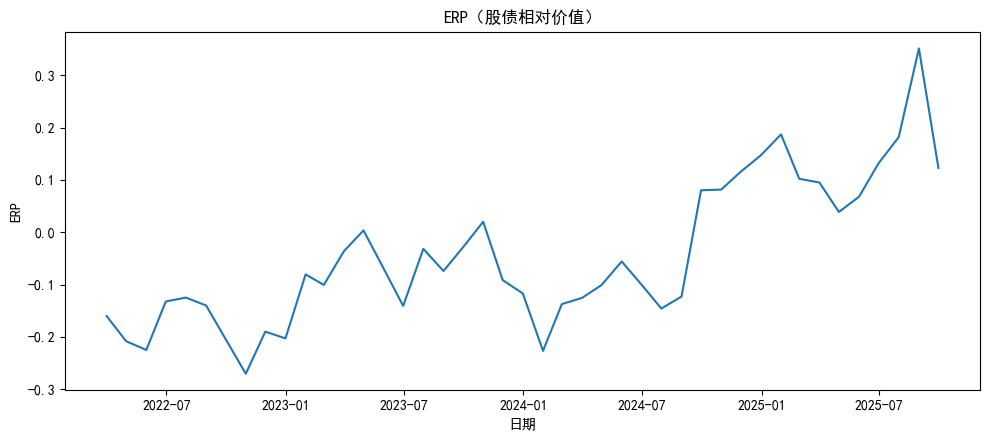

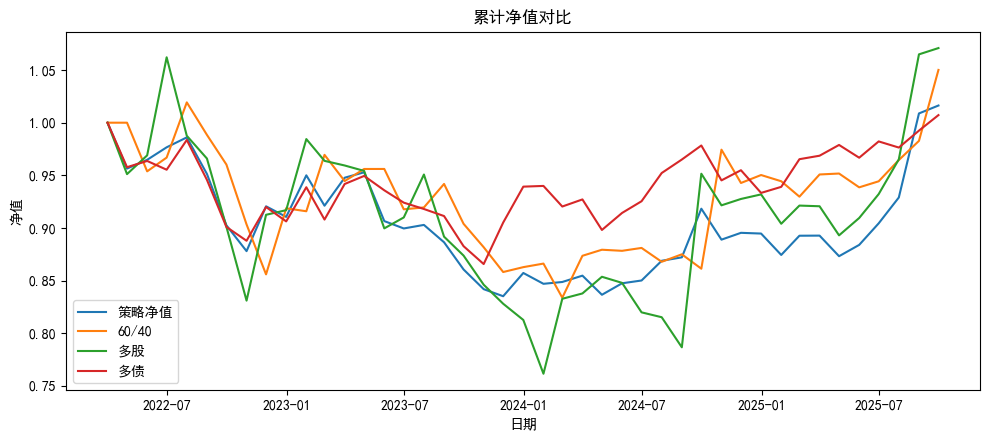

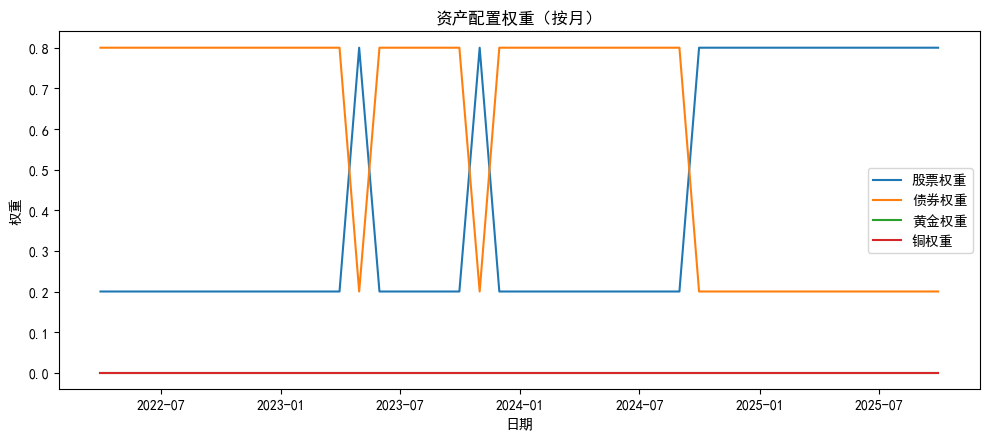

In [9]:
# ============== 绘图（按论文插图风格）==============

# ERP 时间序列
plt.figure(figsize=(10, 4.5))
plt.plot(erp.index, erp.values)
plt.title("ERP（股债相对价值）")
plt.xlabel("日期")
plt.ylabel("ERP")
plt.tight_layout()
plt.savefig("figures/erp_series.png", dpi=150)
plt.show()

# 策略与基准累计净值
plt.figure(figsize=(10, 4.5))
plt.plot(res.index, res["cum_strategy"], label="策略净值")
plt.plot(res.index, res["cum_6040"], label="60/40")
plt.plot(res.index, res["cum_eq"], label="多股")
plt.plot(res.index, res["cum_bd"], label="多债")
plt.legend()
plt.title("累计净值对比")
plt.xlabel("日期")
plt.ylabel("净值")
plt.tight_layout()
plt.savefig("figures/cumulative_returns.png", dpi=150)
plt.show()

# 权重变化
plt.figure(figsize=(10, 4.5))
plt.plot(res.index, res["w_eq"], label="股票权重")
plt.plot(res.index, res["w_bd"], label="债券权重")
if "w_gold" in res.columns:
    plt.plot(res.index, res["w_gold"], label="黄金权重")
if "w_copper" in res.columns:
    plt.plot(res.index, res["w_copper"], label="铜权重")
plt.legend()
plt.title("资产配置权重（按月）")
plt.xlabel("日期")
plt.ylabel("权重")
plt.tight_layout()
plt.savefig("figures/weights.png", dpi=150)
plt.show()

In [10]:
# ============== 导出结果（CSV）==============
out = res.copy()
out["ERP"] = erp.reindex(out.index)
out.to_csv("outputs/strategy_timeseries.csv", encoding="utf-8-sig")
print(
    "已保存：figures/erp_series.png, figures/cumulative_returns.png, figures/weights.png, outputs/strategy_timeseries.csv"
)

已保存：figures/erp_series.png, figures/cumulative_returns.png, figures/weights.png, outputs/strategy_timeseries.csv


In [11]:
# ============== 可选：生成 CSV 模板（便于离线跑）==============
# 运行后会在 ./data 写出示例模板（仅几行，便于你覆盖粘贴真实数据）
from pathlib import Path

base = Path("./data")
base.mkdir(exist_ok=True)


def write_template(name):
    p = base / name
    if not p.exists():
        pd.DataFrame(
            {
                "Date": pd.date_range("2020-01-31", periods=6, freq="ME"),
                "Value": [100, 101, 102, 103, 104, 105],
            }
        ).to_csv(p, index=False)
        print(f"写出模板：{p}")


write_template("equity.csv")
write_template("bond.csv")
# 可选
# write_template("gold.csv")
# write_template("copper.csv")
# write_template("ep.csv")
# write_template("dividend_yield.csv")